Classes trouvées : ['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']

Nombre de fichiers par classe :
backward : 1664 fichiers
bed : 2014 fichiers
bird : 2064 fichiers
cat : 2031 fichiers
dog : 2128 fichiers
down : 3917 fichiers
eight : 3787 fichiers
five : 4052 fichiers
follow : 1579 fichiers
forward : 1557 fichiers
four : 3728 fichiers
go : 3880 fichiers
happy : 2054 fichiers
house : 2113 fichiers
learn : 1575 fichiers
left : 3801 fichiers
marvin : 2100 fichiers
nine : 3934 fichiers
no : 3941 fichiers
off : 3745 fichiers
on : 3845 fichiers
one : 3890 fichiers
right : 3778 fichiers
seven : 3998 fichiers
sheila : 2022 fichiers
six : 3860 fichiers
stop : 3872 fichiers
three : 3727 fichiers
tree : 1759 fichiers
two : 3880 fichiers
up : 3723 fichiers
visual

c:\Users\OO\miniconda3\envs\vocalcmd\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


backward : Durée moyenne ≈ 1.00s, Sample rate = 16000 Hz
bed : Durée moyenne ≈ 0.94s, Sample rate = 16000 Hz
bird : Durée moyenne ≈ 0.87s, Sample rate = 16000 Hz
cat : Durée moyenne ≈ 0.90s, Sample rate = 16000 Hz
dog : Durée moyenne ≈ 1.00s, Sample rate = 16000 Hz
down : Durée moyenne ≈ 0.93s, Sample rate = 16000 Hz
eight : Durée moyenne ≈ 0.96s, Sample rate = 16000 Hz
five : Durée moyenne ≈ 0.98s, Sample rate = 16000 Hz
follow : Durée moyenne ≈ 0.90s, Sample rate = 16000 Hz
forward : Durée moyenne ≈ 0.96s, Sample rate = 16000 Hz
four : Durée moyenne ≈ 0.94s, Sample rate = 16000 Hz
go : Durée moyenne ≈ 0.85s, Sample rate = 16000 Hz
happy : Durée moyenne ≈ 0.88s, Sample rate = 16000 Hz
house : Durée moyenne ≈ 0.95s, Sample rate = 16000 Hz
learn : Durée moyenne ≈ 0.89s, Sample rate = 16000 Hz
left : Durée moyenne ≈ 0.96s, Sample rate = 16000 Hz
marvin : Durée moyenne ≈ 0.97s, Sample rate = 16000 Hz
nine : Durée moyenne ≈ 1.00s, Sample rate = 16000 Hz
no : Durée moyenne ≈ 1.00s, Sample r

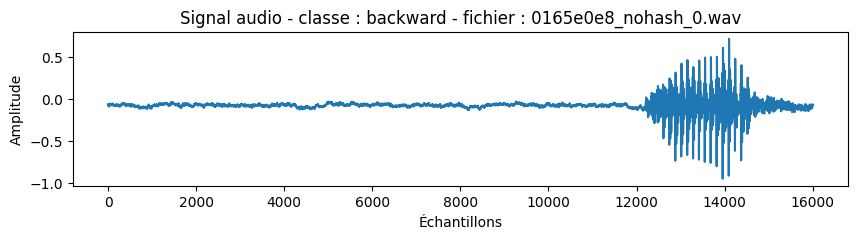

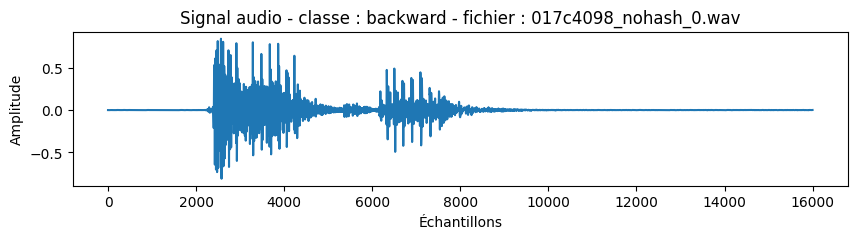

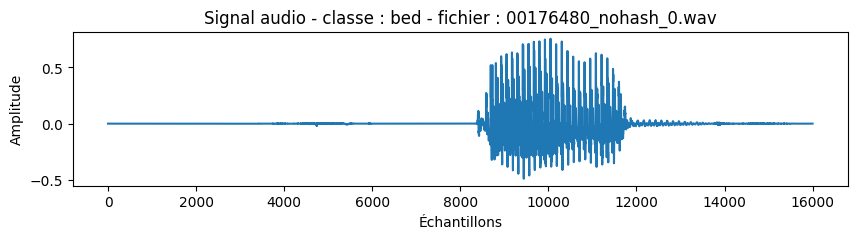

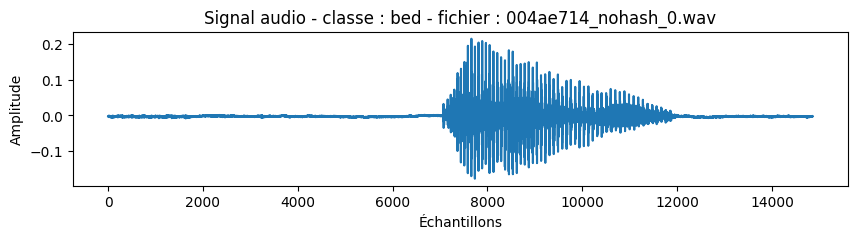

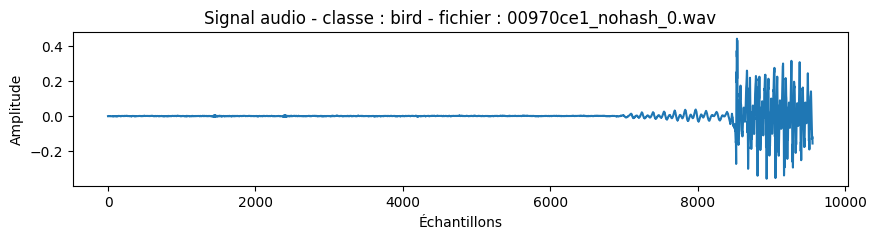

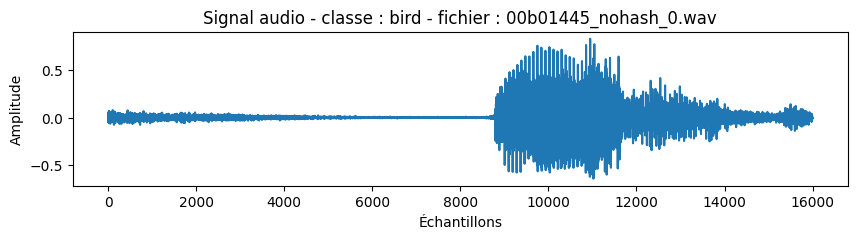

Exploration terminée. Vous connaissez maintenant vos classes, nombre de fichiers, durées et sample rates.


In [1]:
# =====================a=====
# Notebook : 01_exploration.ipynb
# Objectif : Explorer le dataset Google Speech Commands
# ==========================

import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd

# --------------------------
# 1️⃣ Chemin vers le dataset
# --------------------------
dataset_path = "../data/raw"  # mettre ici le chemin correct
classes = [
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d))
    and not d.startswith("_")
]
print("Classes trouvées :", classes)

# --------------------------
# 2️⃣ Nombre de fichiers par classe
# --------------------------
print("\nNombre de fichiers par classe :")
for c in classes:
    n_files = len(os.listdir(os.path.join(dataset_path, c)))
    print(f"{c} : {n_files} fichiers")

# --------------------------
# 3️⃣ Durée moyenne et sample rate
# --------------------------
print("\nDurée moyenne et sample rate par classe :")
for c in classes:
    dur_list = []
    sr_list = []
    
    files = [
        f for f in os.listdir(os.path.join(dataset_path, c))
        if f.endswith(".wav")
    ]
    
    for f in files[:10]:
        file_path = os.path.join(dataset_path, c, f)
        audio, sr = librosa.load(file_path, sr=None)
        dur_list.append(len(audio)/sr)
        sr_list.append(sr)
        
    if dur_list:  # éviter erreur si dossier vide
        print(f"{c} : Durée moyenne ≈ {np.mean(dur_list):.2f}s, Sample rate = {sr_list[0]} Hz")
# --------------------------
# 4️⃣ Visualisation de quelques fichiers audio
# --------------------------
n_samples_to_plot = 2  # nombre de fichiers à visualiser par classe
for c in classes[:3]:  # on prend les 3 premières classes pour l'exemple
    files = os.listdir(os.path.join(dataset_path, c))[:n_samples_to_plot]
    for f in files:
        file_path = os.path.join(dataset_path, c, f)
        audio, sr = librosa.load(file_path, sr=None)
        plt.figure(figsize=(10,2))
        plt.plot(audio)
        plt.title(f"Signal audio - classe : {c} - fichier : {f}")
        plt.xlabel("Échantillons")
        plt.ylabel("Amplitude")
        plt.show()
        # Jouer l'audio directement dans le notebook
        display(ipd.Audio(audio, rate=sr))

# --------------------------
# ✅ Fin exploration
print("Exploration terminée. Vous connaissez maintenant vos classes, nombre de fichiers, durées et sample rates.")